In [27]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator

import os
load_dotenv()
api_key = os.environ.get("OPENAI_API_KEY")

In [2]:
model = ChatOpenAI()

In [4]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    discriminant: float
    equation : str
    result : str

In [6]:
def show_equation(state: QuadState) -> dict:
    equation = f"The quadratic equation is: {state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {"equation": equation}

In [8]:
def check_discriminant(state: QuadState) -> dict:
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {"discriminant": discriminant}

In [17]:
def real_roots(state: QuadState) -> dict:
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    result = f"The real roots are {root1} and {root2}"
    return {"result": result}

In [18]:
def repeated_roots(state: QuadState) -> dict:
    root = -state['b'] / (2*state['a'])
    result = f"The repeated root is {root}"
    return {"result": result}

In [19]:
def no_real_roots(state: QuadState) -> dict:

    result = f"No real roots"
    return {"result": result}

In [28]:
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [29]:
#create graph
graph = StateGraph(QuadState)

#create nodes
graph.add_node("show_equation", show_equation)
graph.add_node("check_discriminant", check_discriminant)
graph.add_node("show_result", show_result)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "check_discriminant")
graph.add_conditional_edges("check_discriminant", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()

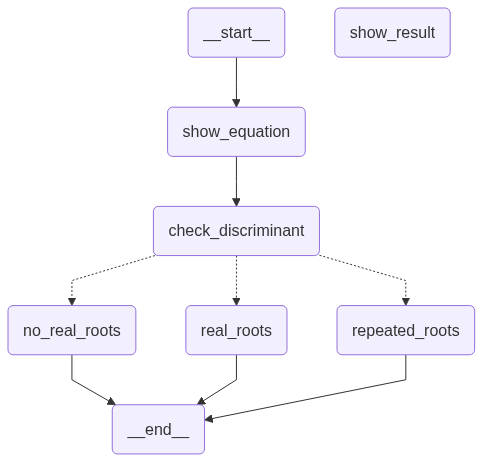

In [31]:
workflow

In [32]:
initial_state = {"a": 4, "b": 2, "c": 2}
final_state = workflow.invoke(initial_state)
final_state

{'a': 4,
 'b': 2,
 'c': 2,
 'discriminant': -28,
 'equation': 'The quadratic equation is: 4x^2 + 2x + 2 = 0',
 'result': 'No real roots'}